# Optimizing APLC Masks with the Augmented Lagrangian

In the [APLC Optimization](APLC_Optimization.ipynb) how-to we dug a dark hole by *summing* a contrast cost and a throughput cost with a hand-tuned weight (the Lagrange multiplier `8e-5`). That **static penalty** has two drawbacks:

1. You have to grid-search the weight to balance contrast against throughput — the notebook itself flags this as "worth its own tutorial."
2. The contrast is never a *target* you ask for directly; it only emerges from whatever the weight happens to produce.

`dygdug`'s `AugmentedLagrangian` poses the *same* design as a **constrained** problem instead:

> maximize throughput &nbsp;&nbsp; subject to &nbsp;&nbsp; (dark-hole contrast ≤ target), &nbsp;&nbsp; 0 ≤ apodizer ≤ 1

It treats the contrast as a **hard constraint** you state directly (e.g. `1e-10`), and updates the Lagrange multipliers **automatically** between solves — so there is no weight to grid-search. It follows the augmented-Lagrangian structure of Por, *Proc. SPIE* **12180**, 121805J (2022).

Two more features make it the right tool for *manufacturable* APLCs:

- **A linear (field) contrast constraint** (`constraint_kind="scaled-field"`) bounds the real and imaginary parts of the dark-hole field. Its feasible set is a polytope whose **vertices are binary**, so maximizing throughput pushes the apodizer toward a binary {0, 1} solution. The `scaled-` variant normalizes the constraint residuals to O(1) so the penalty and multipliers stay well-conditioned.
- **Progressive relaxation** blurs the apodizer between solves to escape local minima (also Por 2022).

This how-to mirrors the setup of the APLC notebook, then swaps in the new optimizer.

## Instrument setup

We reuse the same segmented telescope, focal-plane mask, and Lyot stop as the [APLC Optimization](APLC_Optimization.ipynb) how-to so the results are directly comparable.

In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from prysm.propagation import prepare_executor
from prysm.segmented import VERTEX_TO_VERTEX_TO_FLAT_TO_FLAT
from prysm.mathops import set_backend_to_cupy, np

from dygdug.backend import asnumpy
from dygdug.masks import Pupil, FPM
from dygdug.coropt import VariablePupil
from dygdug.models import Coronagraph

# Define instrument parameters
circumscribed_diameter = 10.95e3
Npup = 128
Nfoc = 128
wvl = 1
fno = 13.66
efl = fno * circumscribed_diameter
lamD = wvl / circumscribed_diameter * efl
px_per_lamD = 4  # the "oversampling"
seg_diam = VERTEX_TO_VERTEX_TO_FLAT_TO_FLAT * 1800

# Variable (amplitude-apodized) entrance pupil
pupil = VariablePupil.hexagonal_segmented(
    Dpup=circumscribed_diameter,
    Npup=Npup,
    rings=3,
    segment_diameter=seg_diam,
    segment_separation=5,
    exclude=(0,),
    mode="amplitude",  # special argument for VariablePupil
)

In [10]:
# Use the GPU backend (optional: comment these two lines out to run on CPU).
#set_backend_to_cupy()
pupil.data = np.asarray(pupil.data)

# prysm executor that controls the propagation
executor = prepare_executor(
    pupil_dx=circumscribed_diameter / Npup,
    pupil_samples=Npup,
    focal_dx=lamD / px_per_lamD,
    focal_samples=Nfoc,
    wavelength=wvl,
    efl=efl,
    focal_shift=(0, 0),
    kind="mdft",
)

# Annular focal-plane mask
fpm = FPM.annular(
    N=Nfoc,
    lamD=lamD,
    px_per_lamD=px_per_lamD,
    inner_radius=3,
    outer_radius=12,
)

# Annular Lyot stop
lyot = Pupil.annular(
    Dpup=circumscribed_diameter,
    Npup=Npup,
    inner_radius=0.2 * circumscribed_diameter / 2,
    outer_radius=0.8 * circumscribed_diameter / 2,
)

coro = Coronagraph(pupil=pupil, fpm=fpm, lyot_stop=lyot, executor=executor)

## Dark hole and contrast target

The dark hole is the same 180°, 3–12 λ/D region as the APLC how-to. The difference is that with the augmented Lagrangian we *also* pick the **contrast we actually want** — here `1e-10` — and hand it to the optimizer as a constraint rather than encoding it in a penalty weight.

In [11]:
from dygdug.masks import annular_mask, ImgSamplingSpec, knife_edge_mask

# Image-plane sampling spec and dark hole
iss = ImgSamplingSpec(Nfoc, px_per_lamD, lamD=lamD)
dark_hole = annular_mask(iss, iwa=3, owa=12, theta_min=-90, theta_max=90)
dark_hole *= knife_edge_mask(iss, iwa=3)

# The contrast we will *require* in the dark hole (relative to the direct PSF peak).
target_contrast = 1e-10

# Reference (no-FPM) peak of the fully-open pupil, used only to normalize the
# coronagraphic intensity for display.  The apodizer is still all-ones here.
ref_field = coro.forward(wvl, include_fpm=False)
contrast_norm = float(np.max(np.abs(ref_field) ** 2))

## Building the AugmentedLagrangian

The optimizer needs the coronagraph, an inner optimizer **class** (not an instance), the dark hole, the wavelength(s), and the contrast target. The key choices:

- `optimizer=PrysmLBFGSB` — the *inner* solver. Each sub-problem is smooth, deterministic, and box-constrained with exact analytic gradients, so quasi-Newton **L-BFGS-B** is the right tool (far fewer iterations than first-order methods like Yogi/Adam).
- `constraint_kind="scaled-field"` — the linear constraint whose binary vertices yield a manufacturable apodizer, with residuals normalized to O(1). (Plain `"field"` residuals live on the scale of `s = sqrt(contrast/2)` ≈ 7e-6, which forces the penalty `rho` to grow enormous before the constraint competes with the O(1) throughput objective — a conditioning disaster for both the inner solves and the multiplier update.)
- `normalize_throughput=True` — optimize *mean* transmission (O(1)) so the throughput objective stays on the same scale as the penalty term.
- `penalty` / `penalty_growth` — the augmented-Lagrangian penalty `rho` and its growth factor. `rho` is multiplied by `penalty_growth` **only when the max violation stalls** (fails to shrink by `constraint_reduction`, default 4×, and is above `constraint_tolerance`) — the standard guarded AL update, so `rho` does not compound blindly across the outer loop.
- `lower_bounds` / `upper_bounds` — the `[0, 1]` box on the amplitude.

`contrast` is the true contrast target; the multipliers and penalty `rho` are updated for you across outer iterations. We start from a fully-open apodizer (all ones) and let the optimizer close it down only as much as the contrast constraint demands.

In [12]:
from prysm.x.optym import PrysmLBFGSB
from dygdug.coropt import AugmentedLagrangian

# Fully-open starting apodizer.
x0 = np.ones_like(pupil.data[pupil.mask], dtype="float64")

model = AugmentedLagrangian(
    coro=coro,
    optimizer=PrysmLBFGSB,
    dark_hole=dark_hole,
    wvl=[wvl],                 # monochromatic, as in the APLC notebook
    contrast=target_contrast,  # the hard dark-hole contrast target
    x0=x0,
    lower_bounds=np.zeros_like(x0),
    upper_bounds=np.ones_like(x0),
    constraint_kind="scaled-field",  # linear (binary-friendly), O(1) residuals
    normalize_throughput=True,
    throughput_weight=1.0,
    penalty=1.0,
    penalty_growth=2.0,        # rho *= 2, but only when the violation stalls
    optimizer_kwargs={"maxls": 50},  # forwarded to PrysmLBFGSB
    ftol=1e-4,  # let inner solves exit early once the objective plateaus
    gtol=1e-6,
)

## The simplest run: `solve()`

`solve(outer_steps, inner_steps)` runs the whole outer loop for you: each outer iteration runs an inner L-BFGS-B solve, then updates the multipliers and grows the penalty. It returns the final apodizer vector and a per-iteration `history` (a list of info dicts).

This enforces the contrast constraint, but expect the result to be **gray, not binary** — the next section explains why and fixes it. Increase `outer_steps` / `inner_steps` for deeper contrast.

outer: 100%|██████████| 20/20 [00:04<00:00,  4.93it/s]


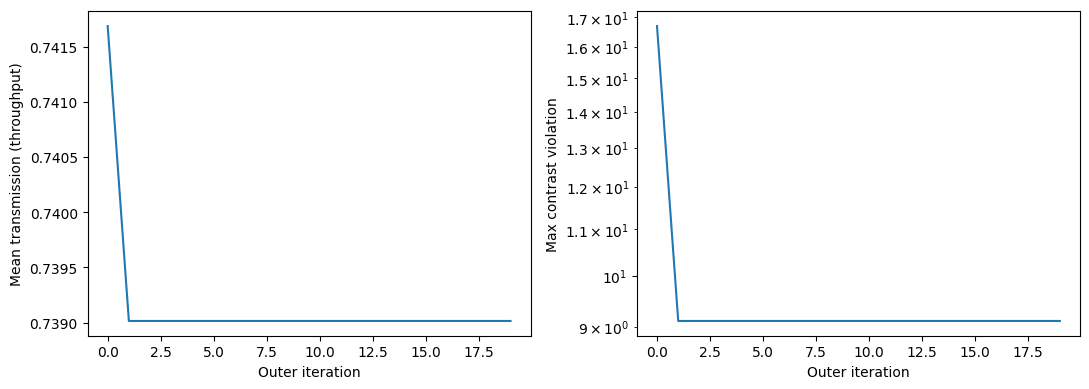

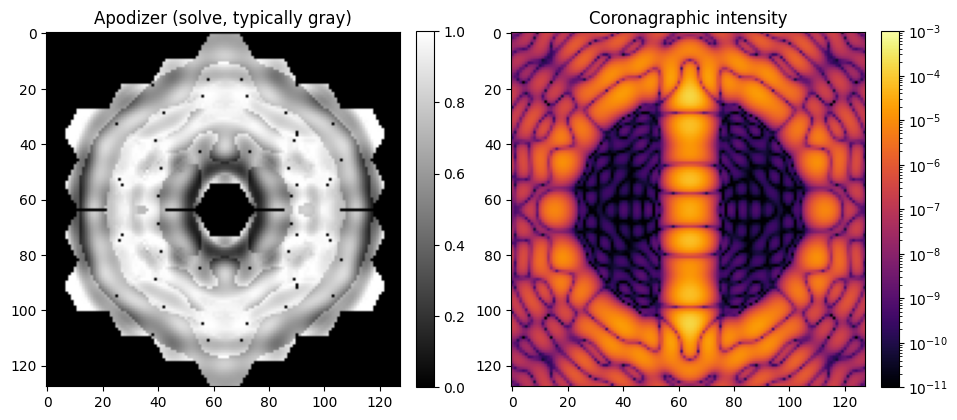

In [13]:
xf, history = model.solve(outer_steps=20, inner_steps=200, progress=True)

pupil.update(xf)
field = coro.forward(wvl, include_fpm=True)
intensity = asnumpy(np.abs(field) ** 2) / contrast_norm

throughput = [h["throughput"] / model.n_params for h in history]
violation = [h["max_violation"] for h in history]

# Convergence diagnostics: violation should fall as the constraint is enforced.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(throughput)
ax[0].set_xlabel("Outer iteration")
ax[0].set_ylabel("Mean transmission (throughput)")
ax[1].plot(violation)
ax[1].set_xlabel("Outer iteration")
ax[1].set_ylabel("Max contrast violation")
ax[1].set_yscale("log")
plt.tight_layout()

# The design and its dark hole (typically gray at this stage).
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].set_title("Apodizer (solve, typically gray)")
im0 = ax[0].imshow(asnumpy(pupil.data), cmap="gray", vmin=0, vmax=1)
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
ax[1].set_title("Coronagraphic intensity")
im1 = ax[1].imshow(intensity, cmap="inferno", norm=LogNorm(vmin=1e-11, vmax=1e-3))
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.show()

## Graduated optimization for a *binary* apodizer

The `solve()` result enforces the constraint but is **gray**, and it is worth understanding why. With `constraint_kind="scaled-field"` the constraints are *linear*, so the feasible set is a polytope whose **vertices are binary** {0, 1} — and maximizing a linear throughput objective should land on a vertex. But the augmented Lagrangian does *not* minimize that pure linear program; its penalty term is a **quadratic**, whose minimizer is *smooth*. A large penalty `rho` rounds the binary vertex off into a gray interior point. Crucially, **running the inner solver longer does not help**: once it has converged, that gray point *is* the minimizer of the smooth objective — to move it you must change the objective, not solve it harder.

The recipe below drives a three-phase schedule by hand with `model.step(...)` (which runs one outer iteration and returns `(x, info)`):

1. **Explore** — dig the dark hole and let the multipliers `lambda` converge to enforce feasibility, letting the guarded update grow `rho` when the violation stalls. We also tighten the contrast target by decades — a *homotopy* from an easy `1e-7` down to the real `1e-10` — and cool the relaxation blur.
2. **Anneal `rho` down + binarize (smoothed tent)** — stop growing `rho` and anneal it toward ~0, holding the converged `lambda`, with `ftol=gtol=None` (run each inner solve to convergence) and the blur off, so the smoothing quadratic vanishes and the problem approaches the pure linear Lagrangian. Simultaneously ramp up a concave binarization penalty that *actively pushes mid-gray pixels to a bound*. Use `binarize_kind="tent"`: its force is **constant toward the nearest bound everywhere, including at mid-gray**. (The default `"quadratic"` double-well has force `~(l + u - 2x)`, which *vanishes* exactly at mid-gray, so it cannot move a stuck 0.5 pixel.) **Always pair the tent with `binarize_smoothing`** (a Huber rounding of its mid-gray kink, here 0.05): the raw tent's gradient is discontinuous, which makes L-BFGS-B's strong-Wolfe line search fail and kills each inner solve after ~1 iteration — the schedule silently degenerates. Watch `info["inner_status"]` / `info["inner_iters"]` for exactly this failure mode.
3. **Fix-and-release rounding** — instead of hard-thresholding the leftover gray rim (which perturbs the dark-hole field with *no feedback*, so the binary design can bust the contrast target), alternately **pin** the pixels that have already decided (`model.pin(threshold)` collapses their bounds onto the nearest of {0, 1}) and run a few more AL steps so the *remaining free pixels restore feasibility around the pinned ones*. Loosening the pin threshold to 0.5 leaves every pixel pinned: the design is binary **by construction**, and the contrast constraint was enforced by the AL on the actual binary design.

> **This schedule is the hard part of APLC design** and the knobs interact. Ramp `binarize_weight` up *gradually and only after feasibility*: too much, too early fights the dark hole and wrecks contrast. There is a genuine **binarity ↔ contrast trade-off** — forcing gray pixels to a bound spends some contrast/throughput — so watch the printed violation as `beta` climbs and through the pin sweeps. Reaching deep contrast at `1e-10` typically needs a larger iteration budget than this short demo; if the final pinned design misses the target, add margin by running the homotopy past the requirement (e.g. to `3e-11`), or increase the re-feasibilization steps per pin.

In [19]:
from tqdm import tqdm

# Rebuild the model, starting fully open again, with strong throughput pressure
# and the smoothed tent binarization penalty available (off until phase 2).
pupil.update(x0)
model = AugmentedLagrangian(
    coro=coro,
    optimizer=PrysmLBFGSB,
    dark_hole=dark_hole,
    wvl=[wvl],
    contrast=target_contrast,
    x0=x0,
    lower_bounds=np.zeros_like(x0),
    upper_bounds=np.ones_like(x0),
    constraint_kind="scaled-field",  # O(1) residuals -> O(1) rho and multipliers
    normalize_throughput=True,
    throughput_weight=30.0,  # strong throughput pressure; ~1 leaves the apodizer gray
    penalty=1.0,
    penalty_growth=2.0,      # guarded: rho *= 2 only when the violation stalls
    optimizer_kwargs={"maxls": 50},
    relaxation_sigma=4.0,    # initial blur; cooled during the explore phase
    binarize_kind="tent",    # constant force toward nearest bound, even at mid-gray
    binarize_smoothing=0.05,  # Huberize the tent's mid-gray kink -- the raw tent's
                              # discontinuous gradient breaks the L-BFGS-B line
                              # search and kills inner solves after ~1 iteration
    binarize_weight=0.0,     # OFF during exploration; ramped up in phase 2
)

n_explore = 60
n_converge = 40
sigma0, sigma_min = 4.0, 0.5   # relaxation kernel std (px), cooled geometrically
c_start = 1e-7                 # easy start for the contrast homotopy, 3 decades
                               # above the target (c_start == target is a no-op!)
rho_floor = 1e-2               # anneal rho down to here in phase 2
beta_max = 1.0               # final tent binarization weight (tune this)

history = []

def log(info):
    history.append(info)
    # A healthy inner solve runs many iterations.  If it exits after ~1 with
    # 'line search failed' / 'no descent direction', the objective has become
    # hostile to L-BFGS-B (e.g. binarization too sharp) and the outer schedule
    # is silently doing nothing -- surface that immediately.
    if info["inner_iters"] <= 2 and info["inner_status"] != "max_inner_steps":
        print(f"  outer {info['outer_iter']}: inner solve exited after "
              f"{info['inner_iters']} iters ({info['inner_status']})")

# --- Phase 1: EXPLORE -- dig the dark hole, converge the multipliers.
for i in tqdm(range(n_explore), desc="explore"):
    frac = i / max(n_explore - 1, 1)
    model.contrast[:] = c_start * (target_contrast / c_start) ** frac  # homotopy
    model.relaxation_sigma = sigma0 * (sigma_min / sigma0) ** frac     # cool blur
    model.ftol, model.gtol = 1e-4, 1e-6                                # early-exit ok
    _, info = model.step(inner_steps=300, apply_relaxation=(i < n_explore - 1))
    log(info)

# --- Phase 2: CONVERGE + BINARIZE -- anneal rho DOWN and ramp the tent UP.
model.penalty_growth = 1.0  # hand rho control to the manual anneal below
rho_explore = model.penalty
for j in tqdm(range(n_converge), desc="converge"):
    b = (j + 1) / n_converge
    model.penalty = rho_explore * (rho_floor / rho_explore) ** b  # anneal rho down
    model.binarize_weight = beta_max * b   # ramp tent binarization up gradually
    model.relaxation_sigma = None          # no blur (it re-grays the apodizer)
    model.ftol, model.gtol = None, None    # run each inner solve to convergence
    _, info = model.step(inner_steps=600, apply_relaxation=False)
    log(info)

# --- Phase 3: FIX-AND-RELEASE -- pin decided pixels, re-feasibilize the rest.
# Each pin collapses the bounds of already-decided pixels onto {0, 1}; the
# following AL steps restore the contrast constraint using only the remaining
# free pixels.  The final threshold=0.5 pin leaves no free pixels, so the
# design is binary by construction -- no post-hoc thresholding.
model.penalty = 1.0        # restore an enforcing penalty (phase 2 annealed it
model.penalty_growth = 2.0  # to ~0, which cannot hold the constraint)
for eps in [0.05, 0.1, 0.2, 0.35, 0.5]:
    pin_info = model.pin(threshold=eps)
    if pin_info["n_free"] > 0:
        for _ in tqdm(range(5), desc=f"re-feasibilize (eps={eps})", leave=False):
            _, info = model.step(inner_steps=300, apply_relaxation=False)
            log(info)
    print(f"eps={eps:0.2f}: pinned {pin_info['n_pinned_total']}/{model.n_params}, "
          f"free {pin_info['n_free']}, violation {model.violation():.2e}")

xf = model.x
pupil.update(xf)

converge:  28%|██▊       | 11/40 [00:03<00:05,  5.35it/s]

  outer 63: inner solve exited after 0 iters (optimizer_stopped)
  outer 64: inner solve exited after 0 iters (optimizer_stopped)
  outer 65: inner solve exited after 0 iters (optimizer_stopped)
  outer 66: inner solve exited after 0 iters (optimizer_stopped)
  outer 67: inner solve exited after 0 iters (optimizer_stopped)
  outer 68: inner solve exited after 0 iters (optimizer_stopped)
  outer 69: inner solve exited after 0 iters (optimizer_stopped)
  outer 70: inner solve exited after 0 iters (optimizer_stopped)


converge:  38%|███▊      | 15/40 [00:04<00:03,  8.27it/s]

  outer 71: inner solve exited after 0 iters (optimizer_stopped)
  outer 72: inner solve exited after 0 iters (optimizer_stopped)
  outer 73: inner solve exited after 0 iters (optimizer_stopped)
  outer 74: inner solve exited after 0 iters (optimizer_stopped)
  outer 75: inner solve exited after 0 iters (optimizer_stopped)
  outer 76: inner solve exited after 0 iters (optimizer_stopped)
  outer 77: inner solve exited after 0 iters (optimizer_stopped)


converge:  55%|█████▌    | 22/40 [00:04<00:01, 13.75it/s]

...

  outer 96: inner solve exited after 2 iters (optimizer_stopped)
  outer 97: inner solve exited after 0 iters (optimizer_stopped)
  outer 98: inner solve exited after 0 iters (optimizer_stopped)
  outer 99: inner solve exited after 1 iters (optimizer_stopped)


  outer 101: inner solve exited after 0 iters (optimizer_stopped)
  outer 102: inner solve exited after 0 iters (optimizer_stopped)
  outer 103: inner solve exited after 0 iters (optimizer_stopped)
  outer 104: inner solve exited after 0 iters (optimizer_stopped)
eps=0.05: pinned 32/10267, free 10235, violation 1.96e+01


  outer 106: inner solve exited after 0 iters (optimizer_stopped)
  outer 107: inner solve exited after 0 iters (optimizer_stopped)
  outer 108: inner solve exited after 0 iters (optimizer_stopped)
  outer 109: inner solve exited after 0 iters (optimizer_stopped)
eps=0.10: pinned 298/10267, free 9969, violation 7.46e+01


eps=0.20: pinned 1677/10267, free 8590, violation 6.25e+02


eps=0.35: pinned 5244/10267, free 5023, violation 1.34e+03
eps=0.50: pinned 10267/10267, free 0, violation 3.21e+03


near-binary fraction: 100.0%
mean transmission (throughput): 0.615


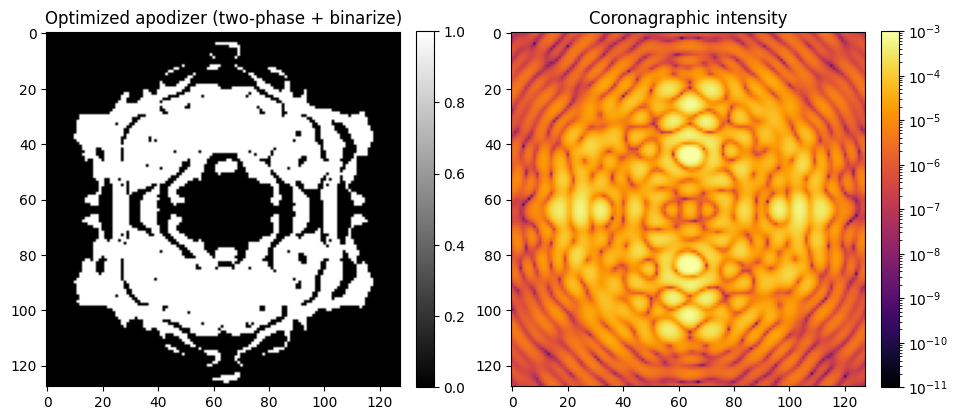

In [20]:
field = coro.forward(wvl, include_fpm=True)
intensity = asnumpy(np.abs(field) ** 2) / contrast_norm

# How binary is the apodizer? Fraction of active pixels within 5% of a bound.
x_host = asnumpy(xf)
near_binary = float(np.mean((x_host < 0.05) | (x_host > 0.95)))
print(f"near-binary fraction: {near_binary:.1%}")
print(f"mean transmission (throughput): {float(np.mean(x_host)):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].set_title("Optimized apodizer (two-phase + binarize)")
im0 = ax[0].imshow(asnumpy(pupil.data), cmap="gray", vmin=0, vmax=1)
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
ax[1].set_title("Coronagraphic intensity")
im1 = ax[1].imshow(intensity, cmap="inferno", norm=LogNorm(vmin=1e-11, vmax=1e-3))
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.show()

## Verify the binary design

The fix-and-release schedule ends with every pixel pinned to a bound, so `xf` is *already* binary — there is no threshold step to spend contrast on. Still, always re-propagate the final design and verify the dark-hole contrast against the target: the last pin (threshold 0.5) rounds whatever gray was left *without* a re-feasibilization solve afterward, so the verification below is what tells you whether the budget was sufficient. If it misses, add margin (run the homotopy past the requirement) or give each pin sweep more re-feasibilization steps.

strictly binary: True
mean transmission (throughput): 0.615
target contrast: 1.0e-10
binary design:   mean 4.60e-05  max 5.43e-04


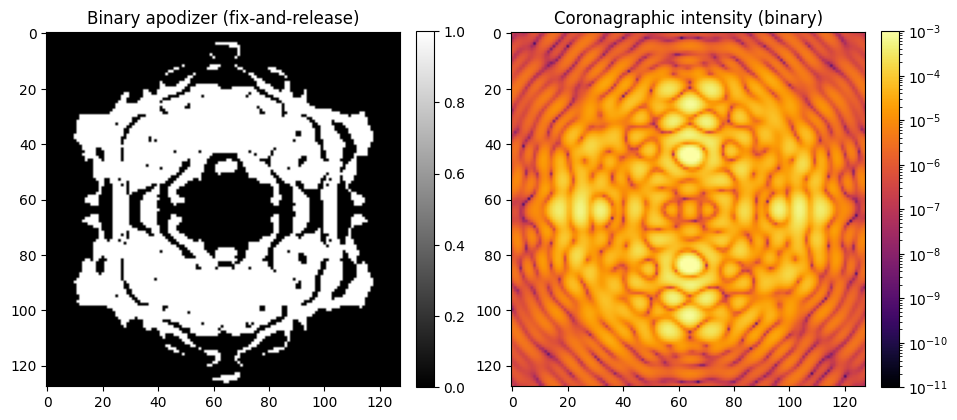

In [21]:
# xf is binary by construction (every pixel pinned to a bound in phase 3).
x_host = asnumpy(xf)
print(f"strictly binary: {bool(((x_host == 0) | (x_host == 1)).all())}")
print(f"mean transmission (throughput): {x_host.mean():.3f}")

dh_host = asnumpy(dark_hole).astype(bool)

# Re-propagate the final design and check the dark hole against the target.
pupil.update(xf)
I_bin = asnumpy(np.abs(coro.forward(wvl, include_fpm=True)) ** 2) / contrast_norm

print(f"target contrast: {target_contrast:.1e}")
print(f"binary design:   mean {I_bin[dh_host].mean():.2e}  max {I_bin[dh_host].max():.2e}")

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].set_title("Binary apodizer (fix-and-release)")
im0 = ax[0].imshow(asnumpy(pupil.data), cmap="gray", vmin=0, vmax=1)
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
ax[1].set_title("Coronagraphic intensity (binary)")
im1 = ax[1].imshow(I_bin, cmap="inferno", norm=LogNorm(vmin=1e-11, vmax=1e-3))
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.show()

## Recap

- `AugmentedLagrangian` poses APLC design as **maximize throughput subject to a hard contrast constraint**, so you state the contrast you want (`1e-10`) instead of grid-searching a penalty weight, and the multipliers update automatically.
- Use `constraint_kind="scaled-field"`: the linear field constraint (binary-friendly vertices) with residuals normalized to O(1), so the penalty `rho` and the multipliers stay well-conditioned. The guarded penalty update grows `rho` only when the violation stalls.
- The **inner** solver is `PrysmLBFGSB` — the right choice for this smooth, box-constrained, analytic-gradient sub-problem. It assumes a *C¹* objective, so pair the `"tent"` binarization penalty with `binarize_smoothing`, and watch `info["inner_status"]` — an inner solve that exits after ~1 iteration with "line search failed" means the schedule is silently doing nothing.
- A bare `solve()` enforces the constraint but is **gray**: the *quadratic* AL penalty has a smooth minimizer, so solving harder (more inner iterations) cannot binarize it — you must change the objective.
- A binary apodizer comes from a three-phase schedule: **explore** (converge multipliers, contrast homotopy from an easy target down to the real one, cool the blur), **anneal `rho` down + ramp the smoothed tent up**, then **fix-and-release rounding** with `model.pin(...)` — pin decided pixels to {0, 1} and let the remaining free pixels restore feasibility, so the final design is binary *by construction* with the contrast enforced on the actual binary design (no post-hoc threshold).
- Expect a **binarity ↔ contrast trade-off**; the schedule knobs need per-problem tuning, and the final verification cell is what tells you the budget was sufficient.

For broadband designs, pass a list of wavelengths to `wvl`; the dark-hole contrast is then constrained at every wavelength simultaneously.